In [66]:
###
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
# import tensorflow as tf
import shutil
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time
pd.set_option('display.max_columns', None)

In [67]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [68]:
# !pip install "numpy<2"

In [69]:
# from google.colab import drive
# drive.mount('/content/drive')

In [70]:
# print(os.listdir())

In [71]:
#os.chdir('/content/drive/My Drive/7643_finalproject02192025')

In [72]:
#!unzip -q "archive.zip" -d "/content/drive/My Drive/7643_finalproject02192025/extract"

# New Section

In [73]:
# os.chdir('/content/drive/My Drive/7643_finalproject02192025/extract') ## small data is in extract

In [74]:
metadata = pd.read_csv(r"cs7643_project_data/MNIST-HAM10000.zip/HAM10000_metadata.csv")
print(metadata.head())
print(metadata.shape)

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
(10015, 7)


In [75]:
print(metadata.dx.unique())
print(metadata.dx_type.unique())

['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']
['histo' 'consensus' 'confocal' 'follow_up']


In [76]:
binary_map = {
    "nv": "benign",
    "bkl":"benign",
    "df": "benign",
    "vasc": "benign",
    "mel": "Not Benign",
    "bcc":  "Not Benign",
    "akiec":  "Not Benign"
}

metadata["target"] = metadata["dx"].map(binary_map)

In [77]:
print(metadata.target.unique())

['benign' 'Not Benign']


In [78]:
lesion_counts = metadata['lesion_id'].value_counts()
metadata['duplicates'] = metadata['lesion_id'].map(lambda x: 'duplicated' if lesion_counts[x] > 1 else 'unduplicated')

In [79]:
print(metadata.head())

     lesion_id      image_id   dx dx_type   age   sex localization  target  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp  benign   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp  benign   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp  benign   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp  benign   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear  benign   

   duplicates  
0  duplicated  
1  duplicated  
2  duplicated  
3  duplicated  
4  duplicated  


In [80]:
## randomly select one image_id for the duplicated ids, if not duplicated, just select the unique one
metadata_unique = metadata.groupby('lesion_id').sample(n=1, random_state=42).reset_index(drop=True)

#metadata_unique = metadata[metadata['duplicates'] == 'unduplicated'].reset_index()
#metadata_unique.drop(['index'], axis=1, inplace=True)

In [81]:
print(metadata_unique.shape)

(7470, 9)


In [82]:
# image_dirs = ['HAM10000_images_part_1', 'HAM10000_images_part_2',
#               'ham10000_images_part_1', 'ham10000_images_part_2']
# merged_image_dir = 'all_images'
# os.makedirs(merged_image_dir, exist_ok=True)

In [83]:


# for img_dir in image_dirs:
#     for fname in os.listdir(img_dir):
#         src = os.path.join(img_dir, fname)
#         dst = os.path.join(merged_image_dir, fname)
#         if not os.path.exists(dst):
#             shutil.copyfile(src, dst)

In [84]:
metadata = metadata_unique

In [85]:
print(metadata.shape)

(7470, 9)


In [86]:
base_dir = r"cs7643_project_data/MNIST-HAM10000.zip/"
metadata['image_path'] = metadata['image_id'] + '.jpg'
metadata['image_folder'] = np.where(metadata['image_id'].str.slice(start=6, stop=12).astype(int)>29305, \
                            'HAM10000_images_part_2/', 'HAM10000_images_part_1/')
metadata['full_path'] = (base_dir + metadata['image_folder'] + metadata['image_path'])
##train_val_df, test_df = train_test_split(metadata, test_size=0.2, stratify=metadata['dx'], random_state=42)
##train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['dx'], random_state=42)

In [87]:
train_val_df, test_df = train_test_split(metadata, test_size=0.2, stratify=metadata['target'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['target'], random_state=42)

In [88]:
print(os.getcwd())

/home/jupyter


In [89]:
print(train_val_df.head())
print(train_val_df['target'].unique())

        lesion_id      image_id   dx    dx_type   age     sex  \
6707  HAM_0006836  ISIC_0025678   nv  follow_up  30.0    male   
5708  HAM_0005804  ISIC_0026275  bcc      histo  85.0    male   
4263  HAM_0004313  ISIC_0026924   nv  follow_up  50.0  female   
5873  HAM_0005975  ISIC_0031837   nv  follow_up  55.0    male   
3414  HAM_0003447  ISIC_0033142   nv      histo  65.0    male   

         localization      target    duplicates        image_path  \
6707             back      benign  unduplicated  ISIC_0025678.jpg   
5708             face  Not Benign    duplicated  ISIC_0026275.jpg   
4263          abdomen      benign  unduplicated  ISIC_0026924.jpg   
5873  lower extremity      benign  unduplicated  ISIC_0031837.jpg   
3414          abdomen      benign    duplicated  ISIC_0033142.jpg   

                 image_folder  \
6707  HAM10000_images_part_1/   
5708  HAM10000_images_part_1/   
4263  HAM10000_images_part_1/   
5873  HAM10000_images_part_2/   
3414  HAM10000_images_part_2/

In [90]:
# def copy_images(df, target_root):
#     for _, row in df.iterrows():
#         #class_dir = os.path.join(target_root,(row['dx']))
#         class_dir = os.path.join(target_root,(row['target']))
#         os.makedirs(class_dir, exist_ok=True)
#         shutil.copyfile(row['full_path'], os.path.join(class_dir, row['image_path']))

# # Create base folders
# os.makedirs('data/train', exist_ok=True)
# os.makedirs('data/val', exist_ok=True)
# os.makedirs('data/test', exist_ok=True)

# copy_images(train_df, 'data/train')
# copy_images(val_df, 'data/val')
# copy_images(test_df, 'data/test') ## only takes 1m 1s

In [91]:
IMG_SIZE = (224, 224)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Transforms for validation & test (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

In [92]:
class HAMDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.classes = sorted(self.df['target'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        label = self.class_to_idx[row['target']]
        if self.transform:
            image = self.transform(image)
        return image, label

In [93]:
train_dataset = HAMDataset(train_df, transform=train_transforms)
val_dataset = HAMDataset(val_df, transform=val_test_transforms)
test_dataset = HAMDataset(test_df, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [94]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

# Move batch to GPU
images = images.to(device)
labels = labels.to(device)
print("On device:", images.device)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
On device: cuda:0


In [95]:
# Load pretrained ResNet101
model = models.resnet101(pretrained=True)

# Optionally freeze all layers (for transfer learning)
for param in model.parameters():
    param.requires_grad = False

# Replace the final FC layer
num_classes = len(train_dataset.classes)  # Should be 7 for HAM10000
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Unfreeze the last ResNet block + FC for fine-tuning
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

# Move model to GPU
model = model.to(device)

/opt/conda/envs/pytorch/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/pytorch/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [96]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

In [97]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
start_time = time.perf_counter()
EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f} | Accuracy: {100 * correct / total:.2f}%")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

Epoch 1/50: 100%|██████████| 150/150 [08:35<00:00,  3.44s/it, acc=86.3, loss=0.169]


Epoch 1 | Loss: 0.2960 | Accuracy: 86.28%


Epoch 2/50: 100%|██████████| 150/150 [08:42<00:00,  3.48s/it, acc=88.2, loss=0.279]


Epoch 2 | Loss: 0.2548 | Accuracy: 88.24%


Epoch 3/50: 100%|██████████| 150/150 [08:26<00:00,  3.38s/it, acc=89, loss=0.245]  


...

Epoch 48 | Loss: 0.1234 | Accuracy: 95.33%


Epoch 49/50: 100%|██████████| 150/150 [08:06<00:00,  3.24s/it, acc=95.2, loss=0.0889]


Epoch 49 | Loss: 0.1146 | Accuracy: 95.21%


Epoch 50/50: 100%|██████████| 150/150 [08:06<00:00,  3.25s/it, acc=95.4, loss=0.0323]

Epoch 50 | Loss: 0.1142 | Accuracy: 95.38%
Execution time: 24769.3497 seconds


In [56]:
model.eval()
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {100 * val_correct / val_total:.2f}%")

/var/tmp/ipykernel_28040/2624392808.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)


ValueError: too many values to unpack (expected 2)

In [ ]:
############## add metadata #####################

In [45]:
print(metadata.isnull().sum())

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
target          0
duplicates      0
image_path      0
image_folder    0
full_path       0
dtype: int64


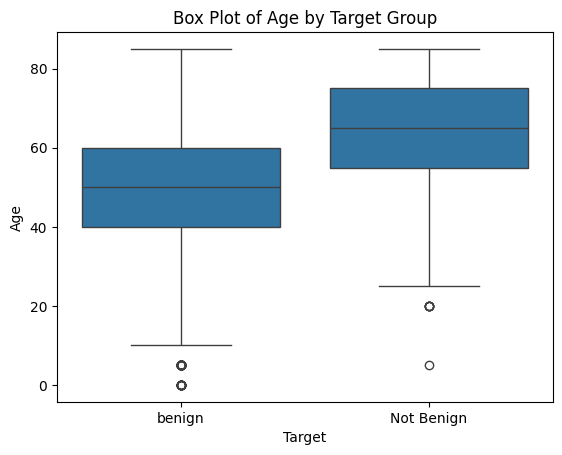

In [46]:
sns.boxplot(x='target', y='age', data=metadata)
plt.title('Box Plot of Age by Target Group')
plt.xlabel('Target')
plt.ylabel('Age')
plt.show()

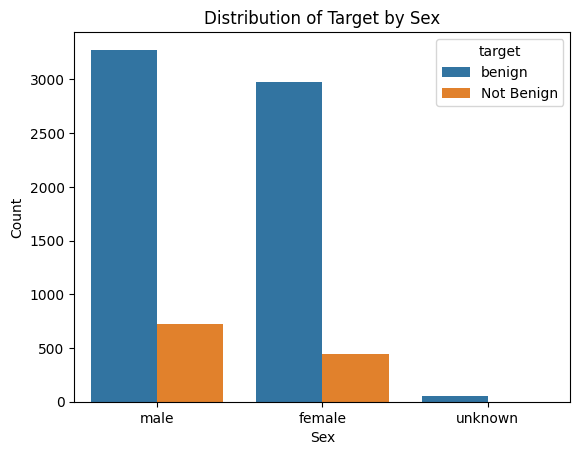

In [47]:
sns.countplot(data=metadata, x='sex', hue='target')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Target by Sex')
plt.show()

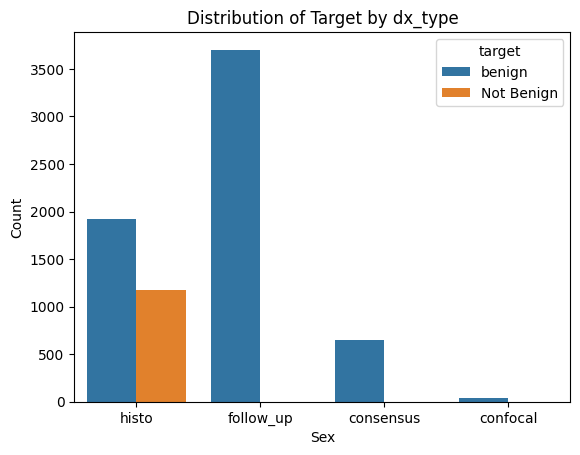

In [48]:
sns.countplot(data=metadata, x='dx_type', hue='target')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Target by dx_type')
plt.show()

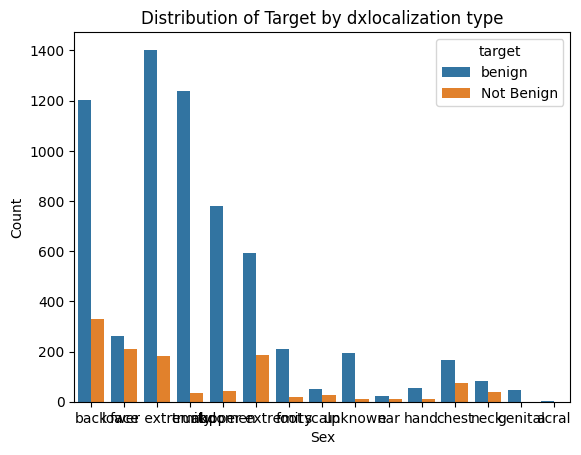

In [49]:
sns.countplot(data=metadata, x='localization', hue='target')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Target by dxlocalization type')
plt.show()

In [98]:
metadata['age'] = metadata['age'].fillna(metadata['age'].median())
df_encoded = pd.get_dummies(metadata[['age', 'sex', 'localization']])

In [99]:
class HAMDataset(Dataset):
    def __init__(self, df, meta_array, transform=None):
        self.df = df.reset_index(drop=True)
        self.meta_array = meta_array
        self.transform = transform
        self.classes = sorted(self.df['target'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
        label = self.class_to_idx[row['target']]
        return image, meta_features, label


In [100]:
from sklearn.preprocessing import StandardScaler

metadata['age'] = metadata['age'].fillna(metadata['age'].median())
metadata['sex'] = metadata['sex'].fillna('unknown')
metadata['localization'] = metadata['localization'].fillna('unknown')
meta_raw = metadata[['age', 'sex', 'localization']].copy()
meta_encoded = pd.get_dummies(meta_raw, columns=['sex', 'localization'])
scaler = StandardScaler()
meta_encoded['age'] = scaler.fit_transform(meta_encoded[['age']])


In [101]:
meta_encoded = meta_encoded.set_index(metadata.index)

# Select metadata rows for each split and convert
train_meta = torch.tensor(meta_encoded.loc[train_df.index].to_numpy().astype(np.float32))
val_meta   = torch.tensor(meta_encoded.loc[val_df.index].to_numpy().astype(np.float32))
test_meta  = torch.tensor(meta_encoded.loc[test_df.index].to_numpy().astype(np.float32))

In [102]:
train_dataset = HAMDataset(train_df, meta_array=train_meta, transform=train_transforms)
val_dataset   = HAMDataset(val_df, meta_array=val_meta, transform=val_test_transforms)
test_dataset  = HAMDataset(test_df, meta_array=test_meta, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [103]:
print(train_dataset.head())

AttributeError: 'HAMDataset' object has no attribute 'head'

In [104]:
def __getitem__(self, idx):
    row = self.metadata.iloc[idx]

    image = Image.open(row['full_path']).convert('RGB')
    if self.transform:
        image = self.transform(image)

    meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
    label = self.class_to_idx[row['target']]

    return image, meta_features, label


In [105]:
class ResNetWithMetadata_old(nn.Module):
    def __init__(self, num_metadata_features, num_classes):
        super(ResNetWithMetadata, self).__init__()
        self.resnet = models.resnet101(pretrained=True)

        # Freeze all layers (optional)
        for param in self.resnet.parameters():
            param.requires_grad = False

        # Replace ResNet's final layer with identity
        self.resnet.fc = nn.Identity()

        # MLP for metadata
        self.meta_fc = nn.Sequential(
            nn.Linear(num_metadata_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

        # Final classifier that combines image and metadata features
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, metadata):
        image_features = self.resnet(image)           # [batch, 2048]
        metadata_features = self.meta_fc(metadata)    # [batch, 32]
        combined = torch.cat((image_features, metadata_features), dim=1)
        output = self.classifier(combined)
        return output

In [106]:
class ResNetWithMetadata(nn.Module):
    def __init__(self, num_metadata_features, num_classes):
        super(ResNetWithMetadata, self).__init__()

        # Load pretrained ResNet101
        self.resnet = models.resnet101(pretrained=True)

        # Unfreeze only the last block (layer4) for fine-tuning
        for name, param in self.resnet.named_parameters():
            param.requires_grad = True if "layer4" in name else False

        # Replace ResNet's classification head with identity
        self.resnet.fc = nn.Identity()

        # Metadata MLP with BatchNorm
        self.meta_fc = nn.Sequential(
            nn.Linear(num_metadata_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        # Optional: Gating mechanism to balance image vs metadata features
        self.gate = nn.Sequential(
            nn.Linear(2048 + 32, 1),
            nn.Sigmoid()
        )

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, metadata):
        # Extract features
        image_features = self.resnet(image)              # [batch, 2048]
        metadata_features = self.meta_fc(metadata)       # [batch, 32]

        # Concatenate both
        combined = torch.cat((image_features, metadata_features), dim=1)  # [batch, 2080]

        # Apply gating (optional attention-like weighting)
        gate_value = self.gate(combined)                 # [batch, 1]
        combined = gate_value * combined                 # scaled features

        # Final classification
        output = self.classifier(combined)
        return output

In [107]:
num_metadata_features = train_meta.shape[1]
num_classes = len(train_dataset.classes)
model = ResNetWithMetadata(num_metadata_features=num_metadata_features,num_classes=num_classes).to(device)


/opt/conda/envs/pytorch/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/pytorch/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [108]:
# import torch.optim as optim

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [109]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        Focal Loss for classification tasks.
        Args:
            alpha (tensor): class weights (shape: [num_classes])
            gamma (float): focusing parameter
            reduction (str): 'mean', 'sum', or 'none'
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


In [110]:
class_weights = torch.tensor([1.0, 5.39], dtype=torch.float32).to(device)
criterion = FocalLoss(alpha=class_weights, gamma=2).to(device)

In [111]:
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim

In [112]:
EPOCHS = 50
save_path = 'best_model.pth'
best_f1 = 0

In [113]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [116]:
def evaluate_model(model, dataloader, device):
    model.eval()
    total = 0
    correct = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, metadata, labels in dataloader:
            images = images.to(device)
            metadata = metadata.to(device)
            labels = labels.to(device)

            outputs = model(images, metadata)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(probs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"✅ Eval Accuracy: {accuracy:.2f}%")
    return all_preds, all_labels, all_probs

In [ ]:
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, metadata, labels in loop:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, metadata)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # 🎯 Training summary
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    val_preds, val_labels, val_probs = evaluate_model(model, val_loader, device)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # 💾 Save best model by F1
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), save_path)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")


🚀 Epoch 1/50


Training Epoch 1/50:   0%|          | 0/150 [00:00<?, ?it/s]/var/tmp/ipykernel_28040/2624392808.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
Training Epoch 1/50: 100%|██████████| 150/150 [08:16<00:00,  3.31s/it, acc=84.4, loss=0.525]


✅ Training Loss: 0.2794 | Accuracy: 84.35%
✅ Eval Accuracy: 84.36%
📊 Validation F1 Score: 0.9152
📈 Validation AUC: 0.9453
🧾 Confusion Matrix:
[[   0  187]
 [   0 1009]]
💾 Saved new best model with F1: 0.9152

🚀 Epoch 2/50


Training Epoch 2/50:   0%|          | 0/150 [00:00<?, ?it/s]/var/tmp/ipykernel_28040/2624392808.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
Training Epoch 2/50: 100%|██████████| 150/150 [08:18<00:00,  3.32s/it, acc=84.4, loss=0.337] 


✅ Training Loss: 0.2689 | Accuracy: 84.35%
✅ Eval Accuracy: 84.36%
📊 Validation F1 Score: 0.9152
📈 Validation AUC: 0.9372
🧾 Confusion Matrix:
[[   0  187]
 [   0 1009]]

🚀 Epoch 3/50


...

✅ Eval Accuracy: 89.97%
📊 Validation F1 Score: 0.9436
📈 Validation AUC: 0.9379
🧾 Confusion Matrix:
[[  73  114]
 [   6 1003]]

🚀 Epoch 49/50


Training Epoch 49/50:   0%|          | 0/150 [00:00<?, ?it/s]/var/tmp/ipykernel_28040/2624392808.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
Training Epoch 49/50: 100%|██████████| 150/150 [08:39<00:00,  3.46s/it, acc=91.9, loss=0.00161]


✅ Training Loss: 0.1272 | Accuracy: 91.88%
✅ Eval Accuracy: 89.13%
📊 Validation F1 Score: 0.9390
📈 Validation AUC: 0.9434
🧾 Confusion Matrix:
[[  65  122]
 [   8 1001]]

🚀 Epoch 50/50


Training Epoch 50/50:   0%|          | 0/150 [00:00<?, ?it/s]/var/tmp/ipykernel_28040/2624392808.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
Training Epoch 50/50: 100%|██████████| 150/150 [08:34<00:00,  3.43s/it, acc=92.8, loss=0.281] 


✅ Training Loss: 0.1254 | Accuracy: 92.76%
✅ Eval Accuracy: 89.63%
📊 Validation F1 Score: 0.9418
📈 Validation AUC: 0.9403
🧾 Confusion Matrix:
[[  68  119]
 [   5 1004]]


In [ ]:
# After training is done:
val_preds, val_labels = evaluate_model(model, val_loader, device)

# Or for test set
test_preds, test_labels = evaluate_model(model, test_loader, device)

/var/tmp/ipykernel_28040/2624392808.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)


✅ Eval Accuracy: 89.63%


ValueError: too many values to unpack (expected 2)

              precision    recall  f1-score   support

  Not Benign       0.93      0.36      0.52       187
      benign       0.89      1.00      0.94      1009

    accuracy                           0.90      1196
   macro avg       0.91      0.68      0.73      1196
weighted avg       0.90      0.90      0.88      1196



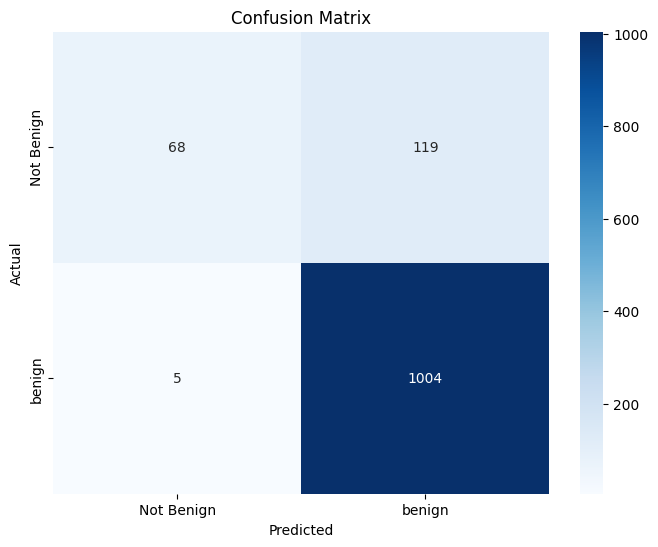

In [119]:
# Print classification report
print(classification_report(val_labels, val_preds, target_names=train_dataset.classes))

# Confusion matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()